# SNE Benchmark Analysis

In [1]:
import re
from pathlib import Path
import pandas as pd

BENCHMARK_DIR = Path("../../../logs/remote/sne_benchmark")
OUTPUT_CSV = Path("aggregated_results.csv")

result_csvs = sorted(BENCHMARK_DIR.glob("*/logs/runs_benchmark/*/job_*_results.csv"))
print(f"Found {len(result_csvs)} result files:")
for p in result_csvs:
    print(f"  {p}")

frames = []
for csv_path in result_csvs:
    job_match = re.search(r"job_(\d+)_results", csv_path.name)
    job_id = int(job_match.group(1)) if job_match else None
    df = pd.read_csv(csv_path)
    df.insert(0, "job_id", job_id)
    df.insert(1, "source_dir", csv_path.parts[-5])  # sne_benchmark_XXXXXXX_N folder
    frames.append(df)

aggregated = pd.concat(frames, ignore_index=True).sort_values("job_id").reset_index(drop=True)

aggregated.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved {len(aggregated)} rows to {OUTPUT_CSV.resolve()}")
aggregated

Found 40 result files:
  ../../../logs/remote/sne_benchmark/sne_benchmark_2817861_7/logs/runs_benchmark/sne_grid_search/job_7_results.csv
  ../../../logs/remote/sne_benchmark/sne_benchmark_2817862_0/logs/runs_benchmark/sne_grid_search/job_0_results.csv
  ../../../logs/remote/sne_benchmark/sne_benchmark_2817863_1/logs/runs_benchmark/sne_grid_search/job_1_results.csv
  ../../../logs/remote/sne_benchmark/sne_benchmark_2817864_2/logs/runs_benchmark/sne_grid_search/job_2_results.csv
  ../../../logs/remote/sne_benchmark/sne_benchmark_2817865_3/logs/runs_benchmark/sne_grid_search/job_3_results.csv
  ../../../logs/remote/sne_benchmark/sne_benchmark_2817870_4/logs/runs_benchmark/sne_grid_search/job_4_results.csv
  ../../../logs/remote/sne_benchmark/sne_benchmark_2817872_5/logs/runs_benchmark/sne_grid_search/job_5_results.csv
  ../../../logs/remote/sne_benchmark/sne_benchmark_2817874_6/logs/runs_benchmark/sne_grid_search/job_6_results.csv
  ../../../logs/remote/sne_benchmark/sne_benchmark_281793

,job_id,source_dir,status,S,N,E,total_envs,wall_time_s,compile_wall_time_s,sim_time_total_s,...,steps_per_sec_per_iter,iter_times_s,ram_per_scene_mean_mb,ram_per_scene_max_mb,vram_allocated_per_scene_mean_mb,vram_allocated_per_scene_max_mb,vram_allocated_total_mb,vram_reserved_per_scene_mean_mb,vram_reserved_per_scene_max_mb,error
0,0,sne_benchmark_2817981_0,ERROR,1,300,32,9600,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,sne_benchmark_2820694_0,ERROR,4,42,2048,344064,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,sne_benchmark_2819563_0,ERROR,2,64,4096,524288,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,sne_benchmark_2819563_0,ERROR,2,96,2048,393216,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,sne_benchmark_2819563_0,OK,1,1,32,32,77.986423,54.230541,14.767095,...,"[113.43288668386943, 525.9497559739867, 526.37...","[7.052628416568041, 1.521057840436697, 1.51983...",2018.582031,2018.582031,10.354980,10.354980,0.0,26.0,26.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1188,7,sne_benchmark_2819561_7,ERROR,1,64,512,32768,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1189,7,sne_benchmark_2817861_7,OK,2,2,64,256,200.625453,90.496801,97.836265,...,"[328.16185753709095, 666.4774587151962, 665.54...","[19.50257122516632, 9.602725367993116, 9.61620...",1811.951172,1818.335938,6.213867,6.213867,0.0,24.0,24.0,NaN
1190,7,sne_benchmark_2820670_7,ERROR,4,48,4096,786432,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1191,7,sne_benchmark_2819561_7,ERROR,1,96,384,36864,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## NOTE THAT 2821177 IS SINGLE GPU RUN

Total rows: 1193
Rows with OK status: 657
Unique (S, N, E) configurations: 441

S range: [1, 80]  (parallel scenes)
N range: [1, 64]  (URDFs per scene)
E range: [32, 4096]  (envs per scene)
Wall time range: [61.51, 5936.58] seconds
total_envs range: [32, 163840]


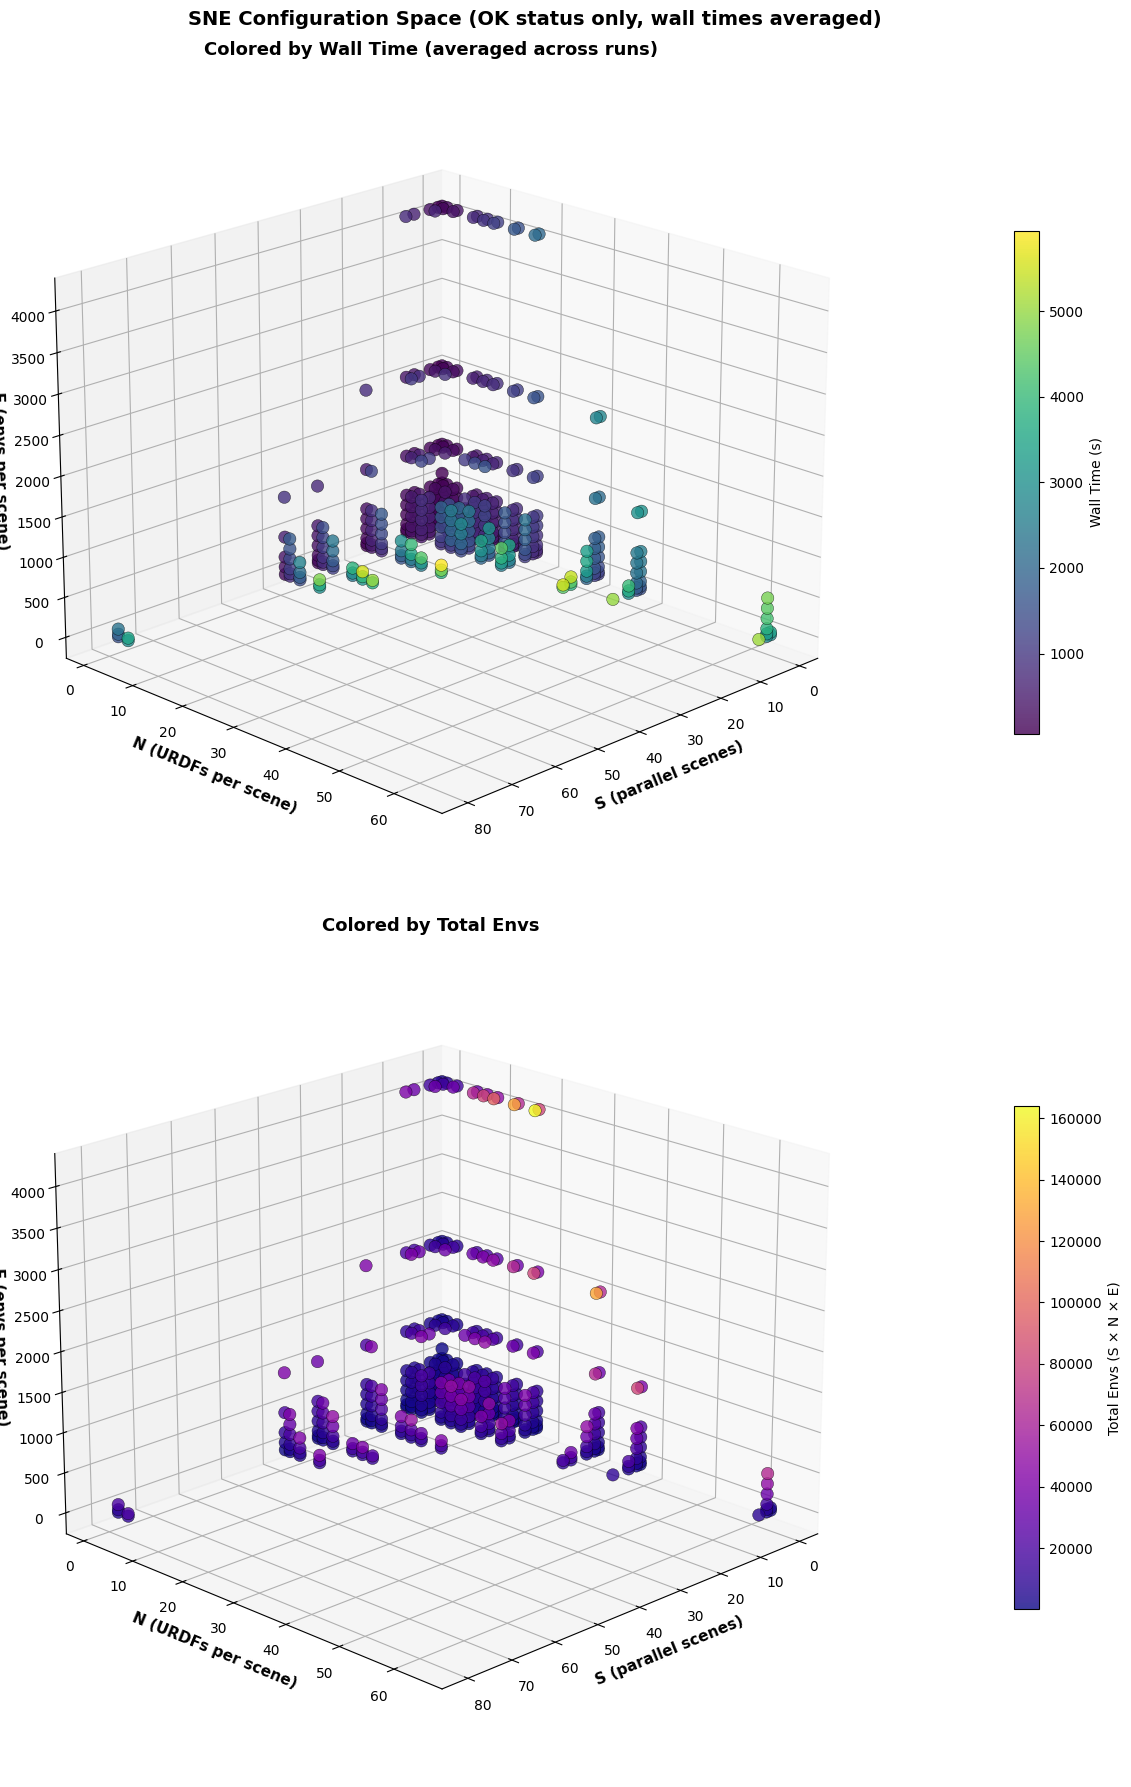

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Filter for OK status only
ok_data = aggregated[aggregated['status'] == 'OK'].copy()
print(f"Total rows: {len(aggregated)}")
print(f"Rows with OK status: {len(ok_data)}")

# Group by (S, N, E) and average wall_time and total_envs
grouped = ok_data.groupby(['S', 'N', 'E']).agg({
    'wall_time_s': 'mean',
    'total_envs': 'first'  # total_envs is deterministic from S, N, E
}).reset_index()

print(f"Unique (S, N, E) configurations: {len(grouped)}")

# Extract SNE configuration values and metrics
S = grouped['S'].values.astype(float)
N = grouped['N'].values.astype(float)
E = grouped['E'].values.astype(float)
wall_time = grouped['wall_time_s'].values.astype(float)
total_envs = grouped['total_envs'].values.astype(float)

print(f"\nS range: [{S.min():.0f}, {S.max():.0f}]  (parallel scenes)")
print(f"N range: [{N.min():.0f}, {N.max():.0f}]  (URDFs per scene)")
print(f"E range: [{E.min():.0f}, {E.max():.0f}]  (envs per scene)")
print(f"Wall time range: [{wall_time.min():.2f}, {wall_time.max():.2f}] seconds")
print(f"total_envs range: [{total_envs.min():.0f}, {total_envs.max():.0f}]")

fig = plt.figure(figsize=(14, 18))

# ===== Plot 1: Colored by Wall Time =====
ax1 = fig.add_subplot(211, projection='3d')
scatter1 = ax1.scatter(S, N, E, c=wall_time, cmap='viridis', s=80, marker='o',
                       edgecolors='black', linewidth=0.3, alpha=0.8)
cbar1 = fig.colorbar(scatter1, ax=ax1, label='Wall Time (s)', pad=0.12, shrink=0.6)
ax1.set_xlabel('S (parallel scenes)', fontsize=11, fontweight='bold')
ax1.set_ylabel('N (URDFs per scene)', fontsize=11, fontweight='bold')
ax1.set_zlabel('E (envs per scene)', fontsize=11, fontweight='bold')
ax1.set_title('Colored by Wall Time (averaged across runs)', fontsize=13, fontweight='bold')
ax1.view_init(elev=20, azim=45)

# ===== Plot 2: Colored by Total Envs =====
ax2 = fig.add_subplot(212, projection='3d')
scatter2 = ax2.scatter(S, N, E, c=total_envs, cmap='plasma', s=80, marker='o',
                       edgecolors='black', linewidth=0.3, alpha=0.8)
cbar2 = fig.colorbar(scatter2, ax=ax2, label='Total Envs (S × N × E)', pad=0.12, shrink=0.6)
ax2.set_xlabel('S (parallel scenes)', fontsize=11, fontweight='bold')
ax2.set_ylabel('N (URDFs per scene)', fontsize=11, fontweight='bold')
ax2.set_zlabel('E (envs per scene)', fontsize=11, fontweight='bold')
ax2.set_title('Colored by Total Envs', fontsize=13, fontweight='bold')
ax2.view_init(elev=20, azim=45)

fig.suptitle('SNE Configuration Space (OK status only, wall times averaged)', fontsize=14, fontweight='bold', y=0.99)

plt.tight_layout()
plt.show()